In [1]:
import torch.nn as nn
import torch
from safetensors.torch import load_file  # comes with HF if safetensors installed
import time
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig
import numpy as np, time
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from scipy.special import softmax
import os
from typing import List
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")

from NACE_helper import NACE_code_structure, NACE_helper
import pandas as pd

np.random.seed(7)

In [2]:
sections_full = NACE_code_structure.level_1 
divisions_full = NACE_code_structure.level_2
classes_full = NACE_code_structure.level_3

In [3]:
# ------------------------------
# 1) Hierarchy
# ------------------------------
sections = {"A": "Agriculture", "C": "Manufacturing", "K": "Financials"}
divisions = {
    #"A": ["1", "2", "3"], 
    "A": ["1", "3"], 
    #"C": ['10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33'], 
    #"C": ['21', '26'], 
    "C": ['21', '26'], 
    "K": ['64', '66'],
    #"K": ['64', '65', '66'],
    }
classes = {
    "1": ['01.5', '01.6'],
    "3": ['03.1', '03.2'],
    "21": ['21.1', '21.2'],
    "26": ["26.1", "26.6"],
    "64": ['64.1', '64.3', '64.9', '64.2'],
    "66":  ['66.1', '66.2', '66.3'], 
    }

division_of_class = {}
section_of_division = {}
for sec, divs in divisions.items():
    for d in divs:
        section_of_division[d] = sec
        for c in classes[d]:
            division_of_class[c] = d
all_classes = list(division_of_class.keys())
all_classes

['01.5',
 '01.6',
 '03.1',
 '03.2',
 '21.1',
 '21.2',
 '26.1',
 '26.6',
 '64.1',
 '64.3',
 '64.9',
 '64.2',
 '66.1',
 '66.2',
 '66.3']

In [4]:
nace_descriptions = pd.read_csv("data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv", sep="\t")
nace_descriptions.head()

,Unnamed: 0,ORDER_KEY,ID,CODE,NAME,PARENT_ID,LEVEL,Includes,IncludesAlso,Excludes,NBR_CHILDREN
0,0,200,A,A,"AGRICULTURE, FORESTRY AND FISHING",NaN,1,This section includes the exploitation of vege...,NaN,NaN,3
1,1,300,1,1,"Crop and animal production, hunting and relate...",A,2,"This division includes two basic activities, n...",This division also includes service activities...,Agricultural activities exclude any subsequent...,7
2,2,350,11,01.1,Growing of non-perennial crops,1,3,This group includes the growing of non-perenni...,NaN,NaN,8
3,3,355,111,01.11,"Growing of cereals (except rice), leguminous c...",11,4,This class includes all forms of growing of ce...,NaN,"This class excludes:\n- growing of rice, see 0...",0
4,4,360,112,01.12,Growing of rice,11,4,This class includes:\n- growing of rice (inclu...,NaN,NaN,0


In [5]:
get_description = lambda code: nace_descriptions[nace_descriptions["CODE"] == code]["NAME"].iloc[0]
get_description("A")

'AGRICULTURE, FORESTRY AND FISHING'

In [6]:
def build_tree_str(sections, divisions, classes, indent="  "):
    lines = []
    for sec_code, sec_name in sorted(sections.items()):
        try: 
            num_sentences = df_statistics_1[df_statistics_1["NACE_Code"] == sec_code]["Sentences"].iloc[0]
        except IndexError:
            num_sentences = 0

        lines.append(f"{sec_code} — {sec_name}: {num_sentences} training samples")

        for div_code in sorted(divisions.get(sec_code, []), key=lambda x: (len(x), x)):
            try: 
                num_sentences = df_statistics_2[df_statistics_2['NACE_Code'] == div_code]['Sentences'].iloc[0]
            except IndexError:
                num_sentences = 0
            lines.append(f"{indent}{div_code}: {get_description(div_code)} {num_sentences}")

            for cls_code in sorted(classes.get(div_code, []), key=lambda x: tuple(map(int, x.split(".")))):
                try: 
                    num_sentences = df_statistics_3[df_statistics_3['NACE_Code'] == cls_code]['Sentences'].iloc[0]
                except IndexError:
                    num_sentences = 0
                lines.append(f"{indent}{indent}{cls_code}: {get_description(cls_code)} {num_sentences}")
    return "\n".join(lines)


print(build_tree_str(sections, divisions, classes))

NameError: name 'df_statistics_1' is not defined

In [ ]:
print(build_tree_str(sections_full, divisions_full, classes_full))


A — AGRICULTURE, FORESTRY AND FISHING: 1372 training samples
  1: Crop and animal production, hunting and related service activities 940
    01.1: Growing of non-perennial crops 43
    01.2: Growing of perennial crops 1
    01.3: Plant propagation 23
    01.4: Animal production 9
    01.5: Mixed farming 191
    01.6: Support activities to agriculture and post-harvest crop activities 193
    01.7: Hunting, trapping and related service activities 0
  2: Forestry and logging 412
    02.1: Silviculture and other forestry activities 13
    02.2: Logging 21
    02.3: Gathering of wild growing non-wood products 3
    02.4: Support services to forestry 22
  3: Fishing and aquaculture 2003
    03.1: Fishing 128
    03.2: Aquaculture 591
B — MINING AND QUARRYING: 9239 training samples
  5: Mining of coal and lignite 169
    05.1: Mining of hard coal 0
    05.2: Mining of lignite 2
  6: Extraction of crude petroleum and natural gas 1630
    06.1: Extraction of crude petroleum 279
    06.2: Extrac

In [ ]:
# load dataset (from DS 2 -> calibration)

dataset_path_3 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3__2nd_approach__nace_level_3__cos_thres_0.35/val_data.csv"
df_val_3 = pd.read_csv(dataset_path_3)
dataset_path_3 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3__2nd_approach__nace_level_3__cos_thres_0.35/train_data.csv"
df_train_3 = pd.read_csv(dataset_path_3)
dataset_path_3 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3__2nd_approach__nace_level_3__cos_thres_0.35/statistics.csv"
df_statistics_3 = pd.read_csv(dataset_path_3)

df_val_3 = df_val_3[df_val_3["NACE_Code"].apply(lambda x: x in all_classes)]

dataset_path_2 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2__2nd_approach__nace_level_2__cos_thres_0.35/val_data.csv"
df_val_2 = pd.read_csv(dataset_path_2)
dataset_path_2 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2__2nd_approach__nace_level_2__cos_thres_0.35/train_data.csv"
df_train_2 = pd.read_csv(dataset_path_2)    
dataset_path_2 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2__2nd_approach__nace_level_2__cos_thres_0.35/statistics.csv"
df_statistics_2 = pd.read_csv(dataset_path_2)
df_val_2 = df_val_2[df_val_2["NACE_Code"].apply(lambda x: x in list(classes.keys()))]

dataset_path_1 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4/val_data.csv"
df_val_1 = pd.read_csv(dataset_path_1)
dataset_path_1 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4/train_data.csv"
df_train_1 = pd.read_csv(dataset_path_1)
dataset_path_1 = "data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4/statistics.csv"
df_statistics_1 = pd.read_csv(dataset_path_1)
df_val_1 = df_val_1[df_val_1["NACE_Code"].apply(lambda x: x in list(sections.keys()))]

X_lvl_1_cal = df_val_1["text"].to_numpy()
y_lvl_1_cal = df_val_1["NACE_Code"].to_numpy()

X_lvl_2_cal = df_val_2["text"].to_numpy()
y_lvl_2_cal = df_val_2["NACE_Code"].to_numpy()

X_lvl_3_cal = df_val_3["text"].to_numpy()
y_lvl_3_cal = df_val_3["NACE_Code"].to_numpy()

X_lvl_3_cal, X_lvl_3_test, y_lvl_3_cal, y_lvl_3_test = train_test_split(X_lvl_3_cal, y_lvl_3_cal, test_size=0.3, random_state=0, stratify=y_lvl_3_cal)

len(X_lvl_1_cal), len(X_lvl_2_cal), len(X_lvl_3_cal)

(7821, 1871, 1553)

In [ ]:
y_lvl_3_cal_lvl_2 = np.vectorize(lambda x: NACE_helper.get_all_level(x)[2])(y_lvl_3_cal)
y_lvl_3_cal_lvl_2

array(['64', '64', '3', ..., '3', '3', '64'], dtype='<U2')

In [ ]:
y_lvl_2_cal_lvl_1 = np.vectorize(NACE_helper.get_level_1_nace)(y_lvl_2_cal)
y_lvl_2_cal_lvl_1

array(['C', 'C', 'C', ..., 'C', 'C', 'C'], dtype='<U1')

In [ ]:
# ------------------------------
# 2) Import BERT Models
# ------------------------------

def load_custom_bert_from_checkpoint(ckpt_path: str, num_layers_base: int = 1, num_labels_base: int = None):
    # 1. Load the saved config (includes custom_hidden, custom_num_layers)
    config = AutoConfig.from_pretrained(ckpt_path)

    full_config = AutoConfig.from_pretrained(ckpt_path.replace(os.path.basename(ckpt_path), "training_config.json"))

    # 2. Build a model from config (bare BertForSequenceClassification)
    model = AutoModelForSequenceClassification.from_config(config)

    # 3. Rebuild the SAME classifier architecture as in training
    hidden = getattr(config, "custom_hidden", 512)  # fallback if not in config
    num_layers = getattr(full_config, "num_layers", num_layers_base)
    num_labels = getattr(config, "num_labels", num_labels_base)

    layers = []
    for i in range(num_layers):
        in_dim = config.hidden_size if i == 0 else hidden
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(nn.GELU())
        layers.append(nn.Dropout(0.2))

    layers.append(nn.Linear(hidden, num_labels))
    model.classifier = nn.Sequential(*layers)

    # 4. Load weights from model.safetensors
    state_dict = load_file(os.path.join(ckpt_path, "model.safetensors"))
    model.load_state_dict(state_dict, strict=True)  # will fail loudly if mismatch

    # 5. Inference mode
    model.eval()
    return model

ckpt_path_sec = "results/BERT_models/NACE_classification/095_results__data_approach_3__desc_lvl_level_1__num_layers_3__cos_thres_0.45bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-768"
# -> All Labels exept G,S,T,N
ckpt_path_sec = "results/BERT_models/NACE_classification/037_results__data_approach_3__desc_lvl_level_1_dataset_2__num_layers_1__cos_thres_0.5bert-base-uncased__train_full_model__some_labels__only_labels/checkpoint-743"

# -> ["A","C","K"]
ckpt_path_sec = "results/BERT_models/NACE_classification/101_results__data_approach_3__desc_lvl_level_1__num_layers_2__cos_thres_0.5bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-77"

# -> ["A","C","K","F","J","N"]
ckpt_path_sec = ""

sec_clf = load_custom_bert_from_checkpoint(ckpt_path_sec)

ckpt_path_div = {
    "A": "results/BERT_models/NACE_classification/NACE_level_2/NACE_class_A/001_results__data_approach_2__num_layers_2__cos_thres_0.4bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-69",
    "C": "results/BERT_models/NACE_classification/NACE_level_2/NACE_class_C/003_results__data_approach_2__num_layers_2__cos_thres_0.4bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-198",
    # This one is for K -> [64,65,66]
    "K": "results/BERT_models/NACE_classification/NACE_level_2/NACE_class_K/001_results__data_approach_2__num_layers_2__cos_thres_0.4bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-634",
    # This one is for K -> [64,66]
    #"K": "results/BERT_models/NACE_classification/NACE_level_2/NACE_class_K/002_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-69",
    # "F": "results/BERT_models/NACE_classification/NACE_level_2/NACE_class_F/001_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-260",
    # "J": "results/BERT_models/NACE_classification/NACE_level_2/NACE_class_J/001_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-48",
    # "N": "results/BERT_models/NACE_classification/NACE_level_2/NACE_class_N/001_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-300", 
} 
div_clf_dict = {k: load_custom_bert_from_checkpoint(v) for k,v in ckpt_path_div.items()}
ckpt_path_cls = {
    "1": "results/BERT_models/NACE_classification/NACE_level_3/NACE_class_1/016_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-45",
    "3": "results/BERT_models/NACE_classification/NACE_level_3/NACE_class_3/001_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-108",
    "21": "results/BERT_models/NACE_classification/NACE_level_3/NACE_class_21/001_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-170",
    "26": "results/BERT_models/NACE_classification/NACE_level_3/NACE_class_26/001_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-39",
    "64": "results/BERT_models/NACE_classification/NACE_level_3/NACE_class_64/001_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-771",
    "66": "results/BERT_models/NACE_classification/NACE_level_3/NACE_class_66/001_results__data_approach_2__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels_no_G__only_labels/checkpoint-225",
} 
cls_clf_dict = {k: load_custom_bert_from_checkpoint(v) for k,v in ckpt_path_cls.items()}

# tokenizer is used for all models
tokenizer = AutoTokenizer.from_pretrained(ckpt_path_sec) 

idx_sec = sec_clf.config.label2id
idx_div_dict = {k: v.config.label2id for k, v in div_clf_dict.items()}
idx_cls_dict = {k: v.config.label2id for k, v in cls_clf_dict.items()}

In [ ]:
import numpy as np

def softmax(x, temperature=1.0):
    """
    Softmax with temperature.

    Args:
        x (array-like): input logits
        temperature (float): temperature parameter (T > 0)

    Returns:
        np.ndarray: probability distribution
    """
    x = np.asarray(x, dtype=np.float64)

    # scale by temperature
    x = x / temperature

    # numerical stability
    x = x - np.max(x)

    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

In [ ]:
TEMPERATURE = 1.0
def BERT_classification_chunk(chunks: List[str], model, tokenizer=tokenizer, temperature=TEMPERATURE) -> List:

    probas = []

    for chunk in chunks: 
        inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits.squeeze(0)

        probas.append(softmax(logits, temperature=temperature))
    return np.array(probas)

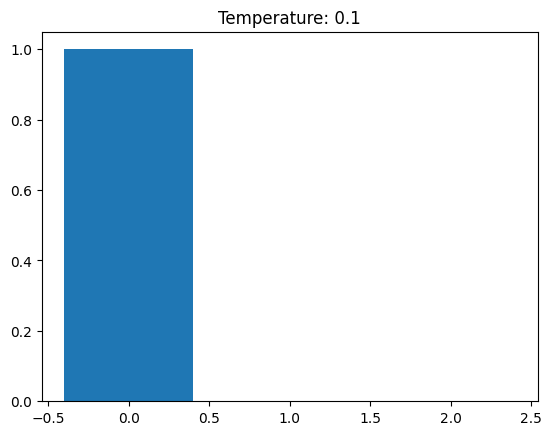

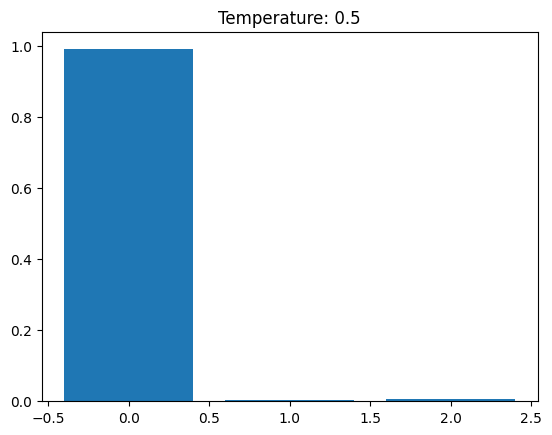

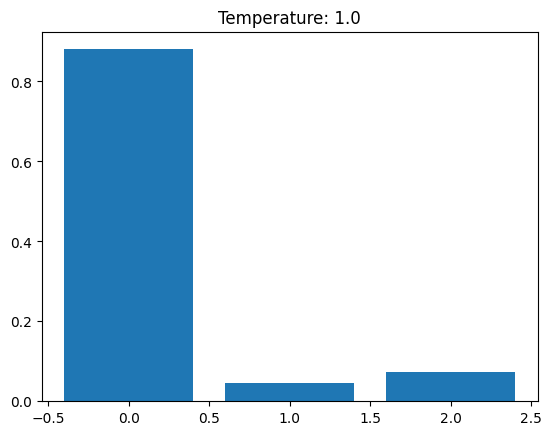

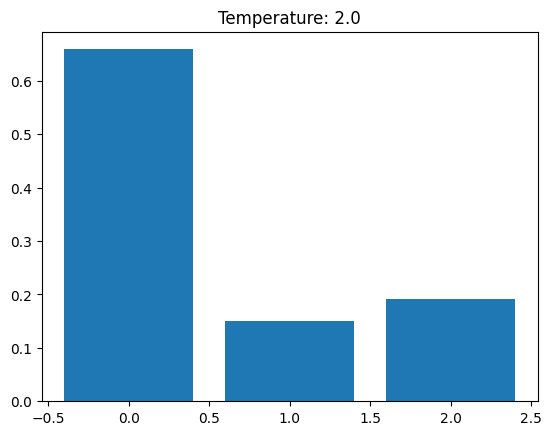

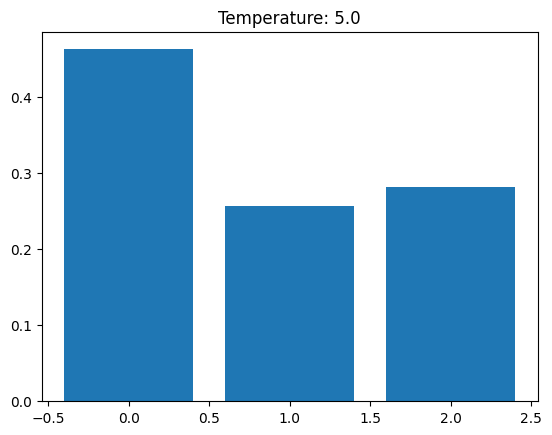

In [ ]:
import matplotlib.pyplot as plt

for i in [0.1, 0.5, 1.0, 2.0, 5.0]:
    probas = BERT_classification_chunk(X_lvl_1_cal[:2], model=sec_clf, temperature=i)
    probas
    plt.figure()
    plt.title(f"Temperature: {i}")
    plt.bar(range(len(probas[0])), probas[0])


In [ ]:
# ------------------------------
# 5) RAPS + reject calibration
# ------------------------------
K_FREE = 1
LAMBDA = 0.05

def renorm_rows(v):
    s = v.sum(axis=1, keepdims=True)
    return np.divide(v, s, out=np.full_like(v, 1.0 / v.shape[1]), where=(s > 0))

def raps_score_rowwise_argsort(P, true_idx, k_free=K_FREE, lam=LAMBDA):
    order = np.argsort(-P, axis=1)
    P_sorted = np.take_along_axis(P, order, axis=1)
    true_mask = (order == true_idx[:, None])
    rank_pos = true_mask.argmax(axis=1)   # exact argsort rank, 0-based
    r = rank_pos + 1
    cumsum = np.cumsum(P_sorted, axis=1)
    cum = cumsum[np.arange(P.shape[0]), rank_pos]
    penalty = lam * np.maximum(0, r - k_free)
    return cum + penalty

def reject_score(P_sec):
    return 1.0 - P_sec.max(axis=1)

def qthr(a, eps):
    return float(np.quantile(a, 1.0-eps, method="higher"))

# Predict probabilities on calibration in batch
t0 = time.time()
print(f"Predict {len(X_lvl_1_cal)} Sections.")
P_sec_cal = BERT_classification_chunk(X_lvl_1_cal, sec_clf)

print(f"Predict {len(X_lvl_2_cal)} Divisions.")
P_div_cal_dict = {k: BERT_classification_chunk(X_lvl_2_cal, v) for k, v in div_clf_dict.items()}

print(f"Predict {len(X_lvl_3_cal)} Classes.")
P_cls_cal_dict = {k: BERT_classification_chunk(X_lvl_3_cal, v) for k, v in cls_clf_dict.items()}
t_prob = time.time() - t0

Predict 7821 Sections.
Predict 1871 Divisions.
Predict 1553 Classes.


In [ ]:
# --- thresholds ---
EPS_SEC = EPS_DIV = EPS_CLS = 0.1
EPS_REJECT = 0.1
MAX_LEAF_SIZE = 3

true_sec_idx = np.array([idx_sec[s] for s in y_lvl_1_cal])
raps_sec_scores = raps_score_rowwise_argsort(P_sec_cal, true_sec_idx)
tau_sec = qthr(raps_sec_scores, EPS_SEC)

In [ ]:
div_clf_dict.keys()

dict_keys(['A', 'C', 'K'])

In [ ]:
# Division threshold: Mondrian-by-parent (true section)
tau_div_dict = {}
for div, _ in div_clf_dict.items():

    #print(f"Get tau for classifier {div}: {idx_div_dict[div].keys()}")

    # Only take correctly chosen sections (lvl 1)
    mask = (y_lvl_2_cal_lvl_1 == div)
    div_scores = np.empty(len(X_lvl_2_cal[mask]))
    if not np.any(mask):
        continue
    
    child = list(idx_div_dict[div].keys())
    child_idx = np.array([idx_div_dict[div][d] for d in child], dtype=int)

    # Probs of the highest scoring class
    P_child = renorm_rows(P_div_cal_dict[div][mask][:, child_idx])
    
    # Right division
    true_div_local = np.array([child.index(d) for d in y_lvl_2_cal[mask]], dtype=int)
    
    # S scores
    div_scores = raps_score_rowwise_argsort(P_child, true_div_local)
    
    # get tau 
    tau_div_temp = qthr(div_scores, EPS_DIV)
    tau_div_dict[div] = tau_div_temp

tau_div_dict

{'A': 0.88983018984842, 'C': 0.8639848202430107, 'K': 0.9545077180264626}

In [ ]:
# Class threshold: Mondrian-by-parent (true division)
tau_cls_dict = {}
for cls_, _ in cls_clf_dict.items(): 
    
    mask = (y_lvl_3_cal_lvl_2 == cls_)
    cls_scores = np.empty(len(X_lvl_3_cal[mask]))
    if not np.any(mask):
        continue
    
    child = list(idx_cls_dict[cls_].keys())
    child_idx = np.array([idx_cls_dict[cls_][c] for c in child], dtype=int)
    
    P_child = renorm_rows(P_cls_cal_dict[cls_][mask][:, child_idx])
    true_cls_local = np.array([child.index(c) for c in y_lvl_3_cal[mask]], dtype=int)

    cls_scores = raps_score_rowwise_argsort(P_child, true_cls_local)
    tau_cls_temp = qthr(cls_scores, EPS_CLS)
    tau_cls_dict[cls_] = tau_cls_temp

tau_cls_dict

{'1': 0.9116993861078507,
 '3': 0.9458850677529222,
 '21': 0.9724085167367025,
 '26': 0.905927592509527,
 '64': 0.8975358536406064,
 '66': 0.9394476917128252}

In [ ]:
# Reject threshold calibrated on in-dist calibration points only
rej_scores_in = reject_score(P_sec_cal)
tau_rej = float(np.quantile(rej_scores_in, 1.0 - EPS_REJECT, method="higher"))

In [ ]:
print("Tau for section:", tau_sec)
print("Tau for each division: ", tau_div_dict)
print("Tau for each class: ", tau_cls_dict)

Tau for section: 0.9002629947582977
Tau for each division:  {'A': 0.88983018984842, 'C': 0.8639848202430107, 'K': 0.9545077180264626}
Tau for each class:  {'1': 0.9116993861078507, '3': 0.9458850677529222, '21': 0.9724085167367025, '26': 0.905927592509527, '64': 0.8975358536406064, '66': 0.9394476917128252}


In [ ]:
# # ------------------------------
# # 6) EXACT set-based metrics (vectorized)
# # ------------------------------
# t0 = time.time()

# rej_cal = (reject_score(P_sec_cal) > tau_rej)
# kept = ~rej_cal

# # Section membership + size
# sec_in_set = (raps_score_rowwise_argsort(P_sec_cal, true_sec_idx) <= tau_sec)
# sec_membership = np.column_stack([
#     (raps_score_rowwise_argsort(P_sec_cal, np.full(len(X_cal), j, dtype=int)) <= tau_sec)
#     for j in range(P_sec_cal.shape[1])
# ])
# sec_set_size = sec_membership.sum(axis=1)

# # Division membership + size (Mondrian true parent)
# div_in_set_mondrian = np.empty(len(X_cal), dtype=bool)
# div_set_size_mondrian = np.empty(len(X_cal), dtype=int)
# for s in sections.keys():
#     mask = (y_sec_cal == s)
#     if not np.any(mask):
#         continue
#     child = divisions[s]
#     child_idx = np.array([idx_div_dict[d] for d in child], dtype=int)
#     P_child = renorm_rows(P_div_cal[mask][:, child_idx])
#     true_div_local = np.array([child.index(d) for d in y_div_cal[mask]], dtype=int)

#     div_in_set_mondrian[mask] = (raps_score_rowwise_argsort(P_child, true_div_local) <= tau_div)
#     memb = np.column_stack([
#         (raps_score_rowwise_argsort(P_child, np.full(P_child.shape[0], j, dtype=int)) <= tau_div)
#         for j in range(P_child.shape[1])
#     ])
#     div_set_size_mondrian[mask] = memb.sum(axis=1)

# # Class membership + size (Mondrian true parent)
# cls_in_set_mondrian = np.empty(len(X_cal), dtype=bool)
# cls_set_size_mondrian = np.empty(len(X_cal), dtype=int)
# for d, child in classes.items():
#     mask = (y_div_cal == d)
#     if not np.any(mask):
#         continue
#     child_idx = np.array([idx_cls_dict[c] for c in child], dtype=int)
#     P_child = renorm_rows(P_cls_cal[mask][:, child_idx])
#     true_cls_local = np.array([child.index(c) for c in y_cls_cal[mask]], dtype=int)

#     cls_in_set_mondrian[mask] = (raps_score_rowwise_argsort(P_child, true_cls_local) <= tau_cls)
#     memb = np.column_stack([
#         (raps_score_rowwise_argsort(P_child, np.full(P_child.shape[0], j, dtype=int)) <= tau_cls)
#         for j in range(P_child.shape[1])
#     ])
#     cls_set_size_mondrian[mask] = memb.sum(axis=1)

# # Hierarchical propagated membership along TRUE path
# div_in_set_hier = sec_in_set & div_in_set_mondrian
# cls_in_set_hier = div_in_set_hier & cls_in_set_mondrian

# # Output-level stats (exact for this tiny hierarchy)
# cls_size_by_div = {}
# for d, child in classes.items():
#     child_idx = np.array([idx_cls_dict[c] for c in child], dtype=int)
#     P_child = renorm_rows(P_cls_cal[:, child_idx])
#     memb = np.column_stack([
#         (raps_score_rowwise_argsort(P_child, np.full(P_child.shape[0], j, dtype=int)) <= tau_cls)
#         for j in range(P_child.shape[1])
#     ])
#     cls_size_by_div[d] = memb.sum(axis=1)

# leaf_union_size = np.zeros(len(X_cal), dtype=int)
# for s, divs_s in divisions.items():
#     s_idx = idx_sec[s]
#     s_in = sec_membership[:, s_idx]
#     add = np.zeros(len(X_cal), dtype=int)
#     for d in divs_s:
#         add += cls_size_by_div[d]
#     leaf_union_size += s_in.astype(int) * add

# reported_level = np.full(len(X_cal), "class_level", dtype=object)
# reported_level[leaf_union_size > MAX_LEAF_SIZE] = "division_level"
# reported_level[rej_cal] = "reject"

# t_exact = time.time() - t0

In [ ]:
# # ------------------------------
# # 7) Print results
# # ------------------------------
# print(f"=== FULLY UNIFIED EXACT METRICS (argsort-identical RAPS), N={N:,} (cal size={len(X_cal):,}) ===")
# print(f"Data generation: {t_gen:.2f}s | Fit: {t_fit:.2f}s | predict_proba: {t_prob:.2f}s | exact-metrics: {t_exact:.2f}s\n")

# print("Thresholds:")
# print("  tau_sec:", tau_sec)
# print("  tau_div:", tau_div)
# print("  tau_cls:", tau_cls)
# print("  tau_rej (1-maxp):", tau_rej, "=> reject if max p_sec <", float(1 - tau_rej))
# print()

# print("Reject stats:")
# print("  reject_rate (all cal):", float(rej_cal.mean()))
# print("  reject_rate on flagged OOD cal points:", float(rej_cal[is_ood_cal].mean()))
# print("  reject_rate on flagged in-dist cal points:", float(rej_cal[~is_ood_cal].mean()))
# print()

# def mean_if(mask, arr_bool):
#     return float(arr_bool[mask].mean()) if np.any(mask) else float("nan")

# def avg_if(mask, arr_num):
#     return float(arr_num[mask].mean()) if np.any(mask) else float("nan")

# print("Coverage (exact set membership):")
# print("  Section coverage (unconditional):", float(sec_in_set.mean()))
# print("  Division coverage (Mondrian, unconditional):", float(div_in_set_mondrian.mean()))
# print("  Class   coverage (Mondrian, unconditional):", float(cls_in_set_mondrian.mean()))
# print("  Division coverage (hierarchical propagated):", float(div_in_set_hier.mean()))
# print("  Class   coverage (hierarchical propagated):", float(cls_in_set_hier.mean()))
# print()

# print("Coverage among KEPT (not rejected):")
# print("  Section coverage | kept:", mean_if(kept, sec_in_set))
# print("  Division Mondrian coverage | kept:", mean_if(kept, div_in_set_mondrian))
# print("  Class   Mondrian coverage | kept:", mean_if(kept, cls_in_set_mondrian))
# print("  Division hierarchical coverage | kept:", mean_if(kept, div_in_set_hier))
# print("  Class   hierarchical coverage | kept:", mean_if(kept, cls_in_set_hier))
# print()

# print("Average set sizes (all cal / kept):")
# print("  |Gamma_sec|:", float(sec_set_size.mean()), "/", avg_if(kept, sec_set_size))
# print("  |Gamma_div(true-parent)|:", float(div_set_size_mondrian.mean()), "/", avg_if(kept, div_set_size_mondrian))
# print("  |Gamma_cls(true-parent)|:", float(cls_set_size_mondrian.mean()), "/", avg_if(kept, cls_set_size_mondrian))
# print()

# print("Backtracking / output-level stats (using MAX_LEAF_SIZE=%d):" % MAX_LEAF_SIZE)
# print("  P(output=reject):", float((reported_level=="reject").mean()))
# print("  P(output=division_level):", float((reported_level=="division_level").mean()))
# print("  P(output=class_level):", float((reported_level=="class_level").mean()))

In [ ]:
sec_labels = sec_clf.config.id2label
div_labels = {k2: v2.config.id2label for k2, v2 in div_clf_dict.items()}
cls_labels = {k2: v2.config.id2label for k2, v2 in cls_clf_dict.items()}

In [ ]:
idx_cls_dict[d]['66.1'], child

(1, ['66.1', '66.2', '66.3'])

In [ ]:
### Test different tau

tau_rej = 0.9
# tau_div_dict = {'A': 0.98, 'C': 0.98, 'K': 1}
# tau_cls_dict = {'1': 0.98,
#  '3': 0.98,
#  '21': 0.98,
#  '26': 0.98,
#  '64': 0.98,
#  '66': 0.98}

In [ ]:
K_FREE = 1
LAMBDA = 0.05

def renorm(v):
    s = float(np.sum(v))
    return v/s if s > 0 else np.ones_like(v)/len(v)

def raps_score_1d(p, j, k_free=K_FREE, lam=LAMBDA):
    order = np.argsort(-p)
    r = int(np.where(order == j)[0][0]) + 1
    return float(np.sum(p[order[:r]]) + lam * max(0, r - k_free))

def raps_set_1d(p, labels, tau):
    print("RAPS scores:")
    for j in range(len(labels)): 
        print(p[j], str(labels[j]), raps_score_1d(p, j), tau, raps_score_1d(p, j) <= tau)
    return [str(labels[j]) for j in range(len(labels)) if raps_score_1d(p, j) <= tau]

def reject_score_1d(pS):
    return float(1.0 - np.max(pS))

def predict_full_one(desc, max_leaf_size=3, temperature=1):
    
    # get 1 level predictio

    pS = BERT_classification_chunk([desc], sec_clf, temperature=temperature)[0]
    rs = reject_score_1d(pS)

    sec_set = raps_set_1d(pS, sec_labels, tau_sec)
    sec_probs = {sec_labels[i]: pS[i] for i in range(len(pS))}

    # if empty return nothing
    if rs > tau_rej:
        return {
            "section_set": [],
            "section_probs": sec_probs,
            "division_sets": {},
            "division_probs": {}, 
            "class_probs": {},
            "class_sets": {},
            "final_output": {"type":"reject", "reason":"low section confidence", "reject_score": rs},
        }

    if len(sec_set) == 0:
        sec_set = [str(sec_labels[int(np.argmax(pS))])]

    # get 2 level prediction (of the children)

    div_sets = {}
    div_probs = {}
    #for s in list(set(sec_labels) & set(sec_set)):
    for s in sec_set: 
        pD = BERT_classification_chunk([desc], div_clf_dict[s], temperature=temperature)[0]
        
        child = list(div_labels[s].values())
        p_child = renorm(np.array([pD[idx_div_dict[s][d]] for d in child]))

        dset = raps_set_1d(p_child, child, tau_div_dict[s])
        if len(dset) == 0:
            dset = [child[int(np.argmax(p_child))]]

        div_probs[s] = {div_labels[s][i]: pD[i] for i in range(len(pD))}
        div_sets[s] = dset

    # get 3 level prediction (of the children)

    cls_sets = {}
    cls_probs = {}
    leaf = []
    for ds in div_sets.values():
        for d in ds:
            if d in cls_clf_dict.keys():
                pC = BERT_classification_chunk([desc], cls_clf_dict[d], temperature=2)[0]
                child = list(cls_labels[d].values())
                p_child = renorm(np.array([pC[idx_cls_dict[d][c]] for c in child]))
                cset = raps_set_1d(p_child, child, tau_cls_dict[d])
                if len(cset) == 0:
                    cset = [child[int(np.argmax(p_child))]]
                cls_sets[d] = cset
                cls_probs[d] = {cls_labels[d][i]: pC[i] for i in range(len(pC))}
                leaf.extend(cset)

    leaf = sorted(set(leaf))
    if len(leaf) <= max_leaf_size:
        final = {"type":"class_level", "codes": leaf}
    else:
        div_out = sorted({d for ds in div_sets.values() for d in ds})
        final = {"type":"division_level", "codes": div_out}

    return {
        "section_set": sec_set,        
        "section_probs": sec_probs,
        "division_sets": div_sets,
        "division_probs": div_probs,
        "class_sets": cls_sets,
        "class_probs": cls_probs,
        "final_output": final,
    }

predict_full_one("manufacture metal tanks containers reservoirs pressure vessels")

RAPS scores:
0.005748706115834106 K 1.1 0.9002629947582977 False
0.02427844332870817 A 1.044251293884166 0.9002629947582977 False
0.9699728505554578 C 0.9699728505554578 0.9002629947582977 False
RAPS scores:
0.4938636696077617 26 0.4938636696077617 0.8639848202430107 True
0.1420813370831389 23 0.8850528279830232 0.8639848202430107 False
0.09188214339100323 21 1.2 0.8639848202430107 False
0.1491078212921227 27 0.6929714908998844 0.8639848202430107 True
0.12306502862597359 10 1.0581178566089968 0.8639848202430107 False
RAPS scores:
0.9019866066161436 26.1 0.9019866066161436 0.905927592509527 True
0.0980133933838564 26.6 1.05 0.905927592509527 False


{'section_set': ['C'],
 'section_probs': {'K': 0.005748706115834106,
  'A': 0.02427844332870817,
  'C': 0.9699728505554578},
 'division_sets': {'C': ['26', '27']},
 'division_probs': {'C': {'26': 0.4938636696077617,
   '23': 0.1420813370831389,
   '21': 0.09188214339100323,
   '27': 0.1491078212921227,
   '10': 0.12306502862597359}},
 'class_sets': {'26': ['26.1']},
 'class_probs': {'26': {'26.1': 0.9019866066161436,
   '26.6': 0.0980133933838564}},
 'final_output': {'type': 'class_level', 'codes': ['26.1']}}

### Test on Paragraphs

In [ ]:
false_positives_lvl_1 = []
false_positives_lvl_2 = []
false_positives_lvl_3 = []

true_lvl_1 = []
true_lvl_2 = []
true_lvl_3 = []

for i in range(20):
#for i in range(len(X_lvl_3_test)):
    desc = X_lvl_3_test[i]
    # ts, td, tc = y_sec_cal[i], y_div_cal[i], y_cls_cal[i]

    tc = y_lvl_3_test[i]
    td = [div for div, cls_ in classes.items() if tc in cls_][0]
    ts = [sec for sec, divs in divisions.items() if td in divs][0]
    
    pred = predict_full_one(desc, max_leaf_size=3)

    y_lvl_3_test

    print("\n==================================================")
    print(f"Description {i}:\n ", desc)
    print(f"True: section={ts}, division={td}, class={tc}")
    print("Section set:", pred["section_set"])
    print("Section probs:", pred["section_probs"])
    print("Division sets:", pred["division_sets"])
    print("Division probs:", pred["division_probs"])
    print("Class sets:", pred["class_sets"])
    print("Class probs:", pred["class_probs"])
    print("Final output:", pred["final_output"])   

    # How good is the prediction
    print("Evaluation:")     
    true = (ts in pred["section_set"])
    true_lvl_1.append(true)
    print("Right class in Level 1?", true)
    print("Level 1 Empty?", (len(pred["section_set"])==0))
    fp = not(ts in pred["section_set"]) and not(len(pred["section_set"])==0)
    false_positives_lvl_1.append(fp)
    print("False Positive: ", fp)
    print()

    divisions_list = [x for k, v in pred["division_sets"].items() for x in v]
    true = (td in divisions_list)
    true_lvl_2.append(true)
    #print("Right class in Level 2 or Level 2 empty? ", (td in divisions_list) or (len(pred["division_sets"])==0))
    print("Right class in Level 2?", true)
    print("Level 2 Empty?", (len(pred["division_sets"])==0))
    fp = not(td in divisions_list) and not(len(pred["division_sets"])==0)
    false_positives_lvl_2.append(fp)
    print("False Positive: ", fp)
    print()

    class_list = [x for k, v in pred["class_sets"].items() for x in v]
    true = (tc in class_list)
    true_lvl_3.append(true)
    #print("Right class in Level 3 or Level 3 empty? ", (tc in class_list) or (len(pred["class_sets"])==0))
    print("Right class in Level 3?", true)
    print("Level 3 Empty?", (len(pred["class_sets"])==0))
    fp = not(tc in class_list) and not(len(pred["class_sets"])==0)
    false_positives_lvl_3.append(fp)
    print("False Positive: ", fp)
    print()

RAPS scores:
0.9938540055709767 K 0.9938540055709767 0.9002629947582977 False
0.0032338892775969925 A 1.0470878948485738 0.9002629947582977 False
0.0029121051514263523 C 1.1 0.9002629947582977 False
RAPS scores:
0.0006719961386691192 64 1.1 0.9545077180264626 False
0.9960784051874176 66 0.9960784051874176 0.9545077180264626 False
0.0032495986739132293 65 1.0493280038613308 0.9545077180264626 False
RAPS scores:
0.07958524146208534 66.3 0.9950199461835328 0.9394476917128252 False
0.8654347047214475 66.1 0.8654347047214475 0.9394476917128252 True
0.054980053816467235 66.2 1.1 0.9394476917128252 False

Description 0:
  at billion billion pfandbriefe accounted for more than half of the total volume. unsecured funding accounted for billion billion with almost all of the volume issued as senior preferred bonds. most transactions were denominated in euro and were placed as fixedrate bonds. unhedged interest rate exposures are usually hedged by swapping fixed into floating interest rates. to mi

In [ ]:
print("false_positives_lvl_1: ", np.mean(false_positives_lvl_1))
print("false_positives_lvl_2: ", np.mean(false_positives_lvl_2))
print("false_positives_lvl_3: ", np.mean(false_positives_lvl_3))

print("true_lvl_1: ", np.mean(true_lvl_1))
print("true_lvl_2: ", np.mean(true_lvl_2))
print("true_lvl_3: ", np.mean(true_lvl_3)) 

false_positives_lvl_1:  0.1
false_positives_lvl_2:  0.7
false_positives_lvl_3:  0.25
true_lvl_1:  0.9
true_lvl_2:  0.3
true_lvl_3:  0.3


## Test for Desc Pages

In [ ]:
# use description pages

dataset_path = "data/datasets/stoxx_600"

over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

nace_classes_full = pd.read_csv(over_view_df_path, index_col=0, sep=";")



In [ ]:
nace_classes = nace_classes_full[nace_classes_full["description_page"].notna()]
nace_classes

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,description_page
107,AAK AB,AAK-SE,AAK-SE,4741.086317,4010.433824,3939.34280627966,10.89,C,AAK AB1.pdf,3
94,ABB Ltd.,ABBN-CH,ABBN-CH,28073.948473,29665.651960,30586.3762461154,27.11,C,ABB Ltd.2.pdf,18
135,Accelleron Industries AG,ACLN-CH,ACLN-CH,742.680345,846.217532,NaN,28.11,C,Accelleron Industries AG1.pdf,7
296,Acciona SA,ANA-ES,ANA-ES,11195.000000,17021.000000,19190,41.20,F,Acciona SA2.pdf,7
365,Accor SA,AC-FR,AC-FR,4224.000000,5056.000000,5606,55.10,I,Accor SA1.pdf,5
...,...,...,...,...,...,...,...,...,...,...
69,Orkla ASA,ORK-NO,ORK-NO,5774.960695,5932.590483,6073.67720031738,10.89,C,Orkla ASA1.pdf,11
598,Scout24 SE,G24-DE,G24-DE,447.539000,509.114000,s,96.09,S,Scout24 SE3.pdf,41
286,Severn Trent Plc,SVT-GB,SVT-GB,2505.264229,2709.430915,NaN,36.00,E,Severn Trent Plc1.pdf,8
133,Siemens Energy AG,ENR-DE,ENR-DE,29005.000000,31119.000000,34465,27.33,C,Siemens Energy AG1.pdf,5


In [ ]:
description_page_path = "data/datasets/stoxx_600/company_descriptions_txt/"

In [ ]:
nace_classes["NACE_lvl_3"] = nace_classes["NACE"].apply(lambda x: NACE_helper.get_all_level(x)[3])
nace_classes = nace_classes[nace_classes["NACE_lvl_3"].apply(lambda x: x in all_classes)]

/tmp/ipykernel_848414/4104711228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nace_classes["NACE_lvl_3"] = nace_classes["NACE"].apply(lambda x: NACE_helper.get_all_level(x)[3])


In [ ]:
nace_classes = nace_classes.sort_values(by="NACE_letter")
nace_classes

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,description_page,NACE_lvl_3
1,Bakkafrost P/F,BAKKA-NO,BAKKA-NO,929.503079,937.862170,973.053513491168,3.21,A,Bakkafrost PF2.pdf,4,03.2
132,Alcon AG,ALC-CH,ALC-CH,8294.208061,8745.595513,9162.50793328229,26.60,C,Alcon AG1.pdf,47,26.6
125,argenx SE,ARGX-BE,ARGX-BE,390.824013,1134.306078,2024.8217775747,21.10,C,argenx SE1.pdf,28,21.1
35,AstraZeneca PLC,AZN-GB,AZN-GB,42199.888931,42373.821732,49989.333053702,21.20,C,AstraZeneca PLC1.pdf,5,21.2
76,Bavarian Nordic A/S,BAVA-DK,BAVA-DK,423.526567,947.164439,765.63798368454,21.20,C,Bavarian Nordic AS1.pdf,6,21.2
129,COMET Holding AG,COTN-CH,COTN-CH,584.204846,409.093151,467.557574915886,26.60,C,COMET Holding AG1.pdf,21,26.6
123,DiaSorin S.p.A.,DIA-IT,DIA-IT,1361.138000,1148.210000,NaN,21.20,C,DiaSorin S.p.A.1.pdf,11,21.2
52,Merck KGaA,MRK-DE,MRK-DE,22232.000000,20993.000000,21156,21.20,C,Merck KGaA2.pdf,4,21.2
475,Allfunds Group plc,ALLFG-NL,ALLFG-NL,493.950000,548.153000,632.100000000053,66.11,K,Allfunds Group plc1.pdf,6,66.1
433,Avanza Bank Holding AB,AZA-SE,AZA-SE,324.377745,410.819403,478.646065026522,66.12,K,Avanza Bank Holding AB1.pdf,4,66.1


In [ ]:
false_positives_lvl_1 = []
false_positives_lvl_2 = []
false_positives_lvl_3 = []

true_lvl_1 = []
true_lvl_2 = []
true_lvl_3 = []

for i, row in nace_classes.iterrows():
#for i, row in nace_classes.loc[460:460].iterrows():
#for i in range(len(X_lvl_3_test)):
    with open(os.path.join(description_page_path,row["Report"].replace("pdf", "txt")), "r") as f: 
        desc = f.read()

    # ts, td, tc = y_sec_cal[i], y_div_cal[i], y_cls_cal[i]

    tc = row["NACE_lvl_3"]
    td = [div for div, cls_ in classes.items() if tc in cls_][0]
    ts = [sec for sec, divs in divisions.items() if td in divs][0]
    
    pred = predict_full_one(desc, max_leaf_size=3)

    y_lvl_3_test

    print("\n==================================================")
    print(f"Description {i}:\n ", desc.replace("\n", " "))
    print(f"True: section={ts}, division={td}, class={tc}")
    print("Section probs:", pred["section_probs"])
    print("Section set:", pred["section_set"])
    print()

    print("Division probs:", pred["division_probs"])
    print("Division sets:", pred["division_sets"])
    print()

    print("Class probs:", pred["class_probs"])
    print("Class sets:", pred["class_sets"])
    print()
    print("Final output:", pred["final_output"])   
    print()

    # How good is the prediction
    print("Evaluation:")     
    true = (ts in pred["section_set"])
    true_lvl_1.append(true)
    print("Right class in Level 1?", true)
    print("Level 1 Empty?", (len(pred["section_set"])==0))
    fp = not(ts in pred["section_set"]) and not(len(pred["section_set"])==0)
    false_positives_lvl_1.append(fp)
    print("False Positive: ", fp)
    print()

    divisions_list = [x for k, v in pred["division_sets"].items() for x in v]
    true = (td in divisions_list)
    true_lvl_2.append(true)
    #print("Right class in Level 2 or Level 2 empty? ", (td in divisions_list) or (len(pred["division_sets"])==0))
    print("Right class in Level 2?", true)
    print("Level 2 Empty?", (len(pred["division_sets"])==0))
    fp = not(td in divisions_list) and not(len(pred["division_sets"])==0)
    false_positives_lvl_2.append(fp)
    print("False Positive: ", fp)
    print()

    class_list = [x for k, v in pred["class_sets"].items() for x in v]
    true = (tc in class_list)
    true_lvl_3.append(true)
    #print("Right class in Level 3 or Level 3 empty? ", (tc in class_list) or (len(pred["class_sets"])==0))
    print("Right class in Level 3?", true)
    print("Level 3 Empty?", (len(pred["class_sets"])==0))
    fp = not(tc in class_list) and not(len(pred["class_sets"])==0)
    false_positives_lvl_3.append(fp)
    print("False Positive: ", fp)
    print()

RAPS scores:
0.0035687592889069946 K 1.1000000000000003 0.9002629947582977 False
0.9688819216143889 A 0.9688819216143889 0.9002629947582977 False
0.02754931909670421 C 1.0464312407110932 0.9002629947582977 False
RAPS scores:
0.0018423829118975044 2 1.1 0.88983018984842 False
0.9916753971843973 3 0.9916753971843973 0.88983018984842 False
0.006482219903705083 1 1.0481576170881024 0.88983018984842 False
RAPS scores:
0.08304982546389057 03.1 1.05 0.9458850677529222 False
0.9169501745361094 03.2 0.9169501745361094 0.9458850677529222 True

Description 1:
  ABOuT BAkkAfrOST  ## About Bakkafrost  <!-- image -->  Key  Resources  ## Our Value Chain  BAKKAFROST: Established in 1968.  Location: Faroe Islands Headquarters, Glyvrar, Eysturoy  Production and business-to-business sale: salmon, packaging, biogas, fish meal, oil and feed.  Longest integrated value chain in the industry: Fully owned subsidiaries: FOF segment Havsbrún, Fuglafjørður (production of fishmeal, -oil and -feed); Bakkafrost Scot

In [ ]:
print("false_positives_lvl_1: ", np.mean(false_positives_lvl_1))
print("false_positives_lvl_2: ", np.mean(false_positives_lvl_2))
print("false_positives_lvl_3: ", np.mean(false_positives_lvl_3))
print("true_lvl_1: ", np.mean(true_lvl_1))
print("true_lvl_2: ", np.mean(true_lvl_2))
print("true_lvl_3: ", np.mean(true_lvl_3))


false_positives_lvl_1:  0.0
false_positives_lvl_2:  0.3333333333333333
false_positives_lvl_3:  0.4
true_lvl_1:  1.0
true_lvl_2:  0.6666666666666666
true_lvl_3:  0.4666666666666667


### With llm summaries

Please summarize the business model in 4 sentences: 

In [68]:
description_page_path_llm_summary = "data/datasets/stoxx_600/company_descriptions_txt_1/"
# from_ = os.path.join(description_page_path,row["Report"].replace("pdf", "txt"))
# to_ = os.path.join(description_page_path_to,row["Report"].replace("pdf", "txt"))

# import shutil

# for i, row in nace_classes.iterrows():
#     from_ = os.path.join(description_page_path,row["Report"].replace("pdf", "txt"))
#     to_ = os.path.join(description_page_path_llm_summary,row["Report"].replace("pdf", "txt"))
#     shutil.copyfile(from_, to_)

In [69]:
nace_classes

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,description_page,NACE_lvl_3
1,Bakkafrost P/F,BAKKA-NO,BAKKA-NO,929.503079,937.862170,973.053513491168,3.21,A,Bakkafrost PF2.pdf,4,03.2
52,Merck KGaA,MRK-DE,MRK-DE,22232.000000,20993.000000,21156,21.20,C,Merck KGaA2.pdf,4,21.2
129,COMET Holding AG,COTN-CH,COTN-CH,584.204846,409.093151,467.557574915886,26.60,C,COMET Holding AG1.pdf,21,26.6
132,Alcon AG,ALC-CH,ALC-CH,8294.208061,8745.595513,9162.50793328229,26.60,C,Alcon AG1.pdf,47,26.6
125,argenx SE,ARGX-BE,ARGX-BE,390.824013,1134.306078,2024.8217775747,21.10,C,argenx SE1.pdf,28,21.1
76,Bavarian Nordic A/S,BAVA-DK,BAVA-DK,423.526567,947.164439,765.63798368454,21.20,C,Bavarian Nordic AS1.pdf,6,21.2
35,AstraZeneca PLC,AZN-GB,AZN-GB,42199.888931,42373.821732,49989.333053702,21.20,C,AstraZeneca PLC1.pdf,5,21.2
123,DiaSorin S.p.A.,DIA-IT,DIA-IT,1361.138000,1148.210000,NaN,21.20,C,DiaSorin S.p.A.1.pdf,11,21.2
291,Bellway p.l.c.,BWY-GB,BWY-GB,4177.814981,3915.032717,2775.47977695465,41.20,F,Bellway p.l.c.1.pdf,18,41.2
296,Acciona SA,ANA-ES,ANA-ES,11195.000000,17021.000000,19190,41.20,F,Acciona SA2.pdf,7,41.2


In [74]:
false_positives_lvl_1 = []
false_positives_lvl_2 = []
false_positives_lvl_3 = []
true_lvl_1 = []
true_lvl_2 = []
true_lvl_3 = []

for i, row in nace_classes.iterrows():
#for i, row in nace_classes.loc[460:460].iterrows():
#for i in range(len(X_lvl_3_test)):
    try: 
        with open(os.path.join(description_page_path_llm_summary,row["Report"].replace("pdf", "txt")), "r") as f: 
            desc = f.read()
    except FileNotFoundError:
        print("File not found:", os.path.join(description_page_path_llm_summary,row["Report"].replace("pdf", "txt")))
        continue

    # ts, td, tc = y_sec_cal[i], y_div_cal[i], y_cls_cal[i]

    tc = row["NACE_lvl_3"]
    td = [div for div, cls_ in classes.items() if tc in cls_][0]
    ts = [sec for sec, divs in divisions.items() if td in divs][0]
    
    print("\n==================================================")
    print(f"Description {i}:\n ", desc.replace("\n", " "))
    
    pred = predict_full_one(desc, max_leaf_size=3, temperature=1)


    print(f"True: section={ts}, division={td}, class={tc}")
    print("Section probs:", pred["section_probs"])
    print("Section set:", pred["section_set"])
    print()

    print("Division probs:", pred["division_probs"])
    print("Division sets:", pred["division_sets"])
    print()

    print("Class probs:", pred["class_probs"])
    print("Class sets:", pred["class_sets"])
    print()
    print("Final output:", pred["final_output"])   
    print()

    # How good is the prediction
    print("Evaluation:")     
    true = (ts in pred["section_set"])
    true_lvl_1.append(true)
    print("Right class in Level 1?", true)
    print("Level 1 Empty?", (len(pred["section_set"])==0))
    fp = not(ts in pred["section_set"]) and not(len(pred["section_set"])==0)
    false_positives_lvl_1.append(fp)
    print("False Positive: ", fp)
    print()

    divisions_list = [x for k, v in pred["division_sets"].items() for x in v]
    true = (td in divisions_list)
    true_lvl_2.append(true)
    #print("Right class in Level 2 or Level 2 empty? ", (td in divisions_list) or (len(pred["division_sets"])==0))
    print("Right class in Level 2?", true)
    print("Level 2 Empty?", (len(pred["division_sets"])==0))
    fp = not(td in divisions_list) and not(len(pred["division_sets"])==0)
    false_positives_lvl_2.append(fp)
    print("False Positive: ", fp)
    print()

    class_list = [x for k, v in pred["class_sets"].items() for x in v]
    true = (tc in class_list)
    true_lvl_3.append(true)
    #print("Right class in Level 3 or Level 3 empty? ", (tc in class_list) or (len(pred["class_sets"])==0))
    print("Right class in Level 3?", true)
    print("Level 3 Empty?", (len(pred["class_sets"])==0))
    fp = not(tc in class_list) and not(len(pred["class_sets"])==0)
    false_positives_lvl_3.append(fp)
    print("False Positive: ", fp)
    print()


Description 1:
  Bakkafrost is a vertically integrated salmon farming company headquartered in the Faroe Islands, controlling the entire value chain from fishmeal, feed, and smolt production to farming, harvesting, processing, packaging, and global sales. It produces and sells high-quality salmon and related products through fully owned subsidiaries across Europe, North America, and Asia, serving mainly Western Europe and North America. The company leverages state-of-the-art facilities, a specialized fleet, and in-house biogas and by-product processing to maximize efficiency, sustainability, and biosecurity. Value is created through premium salmon production, strong market reach, sustainable use of natural resources, and long-term returns for shareholders and local communities.
True: section=A, division=3, class=03.2
Section probs: {'J': 0.0011982489136096667, 'A': 0.9887178991623901, 'K': 0.006674764116217659, 'C': 0.0011072818459238786, 'F': 0.0008454760111492288, 'N': 0.00145632995

In [75]:
len(false_positives_lvl_1)

15

In [ ]:
# Temperatur bei calibrierugn auf 2 angepasst!

print("False Positives in Level 1: ", np.mean(false_positives_lvl_1))
print("False Positives in Level 2: ", np.mean(false_positives_lvl_2))
print("False Positives in Level 3: ", np.mean(false_positives_lvl_3))
print("True Predictions in Level 1: ", np.mean(true_lvl_1))
print("True Predictions in Level 2: ", np.mean(true_lvl_2))
print("True Predictions in Level 3: ", np.mean(true_lvl_3))

False Positives in Level 1:  0.0
False Positives in Level 2:  0.26666666666666666
False Positives in Level 3:  0.4
True Predictions in Level 1:  1.0
True Predictions in Level 2:  0.7333333333333333
True Predictions in Level 3:  0.4666666666666667


In [ ]:
nace_classes_full
nace_classes_full["NACE_lvl_3"] = nace_classes_full["NACE"].apply(lambda x: NACE_helper.get_all_level(x)[3])
nace_classes_full = nace_classes_full[nace_classes_full["NACE_lvl_3"].apply(lambda x: x in all_classes)]
nace_classes_full

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,description_page,NACE_lvl_3
483,3i Group plc,III-GB,III-GB,701.210162,1276.962137,NaN,66.30,K,NaN,NaN,66.3
484,ABN AMRO Bank N.V. Depositary receipts,ABN-NL,ABN-NL,10716.000000,19055.000000,20045,64.19,K,NaN,NaN,64.1
478,Abrdn plc,ABDN-GB,ABDN-GB,1790.871634,1836.208616,1782.59705686569,66.30,K,NaN,NaN,66.3
533,Adyen NV,ADYEN-NL,ADYEN-NL,8935.611000,1863.406000,2181.177,66.19,K,NaN,NaN,66.1
512,Aegon Ltd.,AGN-NL,AGN-NL,53773.000000,22883.000000,NaN,66.22,K,NaN,NaN,66.2
...,...,...,...,...,...,...,...,...,...,...,...
77,UCB S.A.,UCB-BE,UCB-BE,5517.000000,5252.000000,6152,21.20,C,UCB S.A.1.pdf,NaN,21.2
455,UniCredit S.p.A.,UCG-IT,UCG-IT,27973.000000,46765.000000,49196,64.19,K,UniCredit S.p.A.3.pdf,NaN,64.1
525,VZ Holding AG,VZN-CH,VZN-CH,419.120738,534.742315,623.70437912786,66.30,K,NaN,NaN,66.3
450,Wendel SE,MF-FR,MF-FR,6745.900000,7127.600000,8063.5,64.99,K,Wendel SE2.pdf,NaN,64.9


In [ ]:
df_overview = pd.read_csv("data/datasets/reports_subset_from_full_data_3/reports_subset_from_full_data_3_overview.csv", index_col=0)
df_overview["NACE_lvl_3"] = df_overview["NACE"].apply(lambda x: NACE_helper.get_all_level(x)[3])
df_overview.groupby("NACE_lvl_3").count()

,Symbol,Name,Company is Active,Company Founded Date,Country of Primary Listing Iso3,CUSIP,Date Of First Trade,Entity Country HQ,Entity Credit Parent,NACE,...,ISIN,Primary Equity Listing,Proper Name,Public Company,Region Ticker,Sec is Primary Issue,Sec Type,SEDOL,NACE_Letter,Report
NACE_lvl_3,,,,,,,,,,,,,,,,,,,,,
01.1,13,13,13,13,13,13,13,13,13,13,...,13,13,13,13,13,13,13,13,13,13
01.2,2,2,2,2,2,2,1,2,2,2,...,2,2,2,2,2,2,2,2,2,2
01.3,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
01.4,11,11,11,10,11,11,9,11,11,11,...,11,11,11,11,11,11,11,11,11,11
01.5,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92.0,17,17,17,16,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
93.1,14,14,14,13,14,14,12,14,14,14,...,14,14,14,14,14,14,14,14,14,14
93.2,17,17,17,16,17,17,16,17,17,17,...,17,17,17,17,17,17,17,17,17,17
